# 12 · Select knockout guides that agree with each other

Several guides target each gene. A guide that worked should move expression the
same way as the other guides against the same gene; one that did not will look
unrelated to them.

This notebook assembles the coefficients from notebook 10, correlates each
guide's profile against every other, and keeps the guides that agree with
another guide against the same gene. The rest are written out as bad guides and
dropped in notebook 13.

**Reads** the fits selected by `par_guide_lm_model`, from
`par_guide_lm_fit_dir`. Either notebook 10 produces them.
**Writes** `par_guide_lm_weights_file`, `par_guide_lm_pvals_file`,
`par_good_guides_file` and `par_bad_KO_guides_file`.

:::{note}
The fits below take days to run across all guides, so their results are
provided rather than regenerated. `TextFiles/GuideSelect_BadKOGuides.csv` and
`TextFiles/GuideSelect_GoodGuides.csv` hold the guide selection the published
analysis used, and notebook 13 reads the first of them directly.

This notebook records how that selection was made. It writes its own results to
separate files under `outputs/` and leaves the provided lists untouched.
:::


## Setup

In [1]:
from libraries import *
from parameters import *
from pathlib import Path

os.chdir(projectDir)

## Assemble the fits

Notebook 10 writes one tidy row per term per gene. Pivoting gives a guide by
gene matrix of coefficients, and the same for p-values.

In [2]:
have_provided = bool(par_guide_lm_weights_input) and Path(par_guide_lm_weights_input).exists()
have_own_fits = bool(sorted(Path(par_guide_lm_fit_dir).glob("coefs_*_*_*_*.csv")))

if not have_provided and not have_own_fits:
    raise FileNotFoundError(
        f"Nothing to read.\n\n"
        f"Expected either the provided coefficient matrix at\n"
        f"    {par_guide_lm_weights_input}\n"
        f"or the output of a notebook 10 in\n"
        f"    {par_guide_lm_fit_dir}\n\n"
        f"The matrix is downloaded separately; keep the file name "
        f"GuideSelect_weights.csv and put it in "
        f"{par_downloaded_data_dir}/. See TextFiles/README.md.")

if have_provided:
    # A coefficient matrix from an earlier fit, genes by guides.
    provided = pd.read_csv(par_guide_lm_weights_input, index_col=0)
    weights = provided.T
    pvals = None
    print(f"using the provided coefficient matrix: {par_guide_lm_weights_input}")
    print(f"coefficient matrix: {weights.shape[0]} guides x {weights.shape[1]} genes")
    tidy = None
else:
    files = sorted(Path(par_guide_lm_fit_dir).glob("coefs_*_*_*_*.csv"))
    if not files:
        raise FileNotFoundError(
            f"no fits in {par_guide_lm_fit_dir}, and par_guide_lm_weights_input is not set; "
            "run a notebook 10 or point at a provided coefficient matrix")
    print(f"model: {par_guide_lm_model}")
    print(f"coefficient tables: {len(files)}")
    tidy = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    print(f"rows: {len(tidy)}")

if tidy is not None:
    # drop the intercept and the QC covariates; keep the guide terms
    drop_terms = {"(Intercept)", "n_genes", "mt_frac"}
    tidy = tidy[~tidy.term.isin(drop_terms)]
    tidy = tidy[~tidy.term.str.startswith("leiden")]

    weights = tidy.pivot_table(index="term", columns="respGene", values="estimate")
    pvals = tidy.pivot_table(index="term", columns="respGene", values="p.value")
    print(f"coefficient matrix: {weights.shape[0]} guides x {weights.shape[1]} genes")

    weights.T.to_csv(par_guide_lm_weights_file)
    pvals.T.to_csv(par_guide_lm_pvals_file)


using the provided coefficient matrix: data/GuideSelect_weights.csv
coefficient matrix: 3204 guides x 6560 genes


## Correlate guides against each other

Every pair of guides is scored by the Pearson correlation of their coefficient
profiles. Pairs targeting the same gene should score higher than pairs
targeting different genes; that separation is the check that guide selection is
meaningful at all.

In [3]:
weights = weights.dropna(axis=1, how="any")
print(f"genes with a coefficient for every guide: {weights.shape[1]}")

corr = weights.T.corr(method="pearson")

pairs = corr.stack().rename("corr").reset_index()
pairs.columns = ["guide_a", "guide_b", "corr"]
pairs = pairs[pairs.guide_a != pairs.guide_b].copy()

target_of = lambda g: g.rsplit("_", 1)[0]
pairs["gene_a"] = pairs.guide_a.map(target_of)
pairs["gene_b"] = pairs.guide_b.map(target_of)
pairs["same_gene"] = pairs.gene_a == pairs.gene_b

# The correlation matrix is flattened whole, so each unordered pair appears in
# both directions. They are kept, as in the original analysis: it does not
# change which guides are selected, and it is what the saved pair table counts.

print(pairs.groupby("same_gene")["corr"].describe()[["count", "mean", "50%"]].to_string())

genes with a coefficient for every guide: 6560
                count      mean       50%
same_gene                                
False      10256342.0  0.002240  0.002081
True           6070.0  0.028212  0.010450


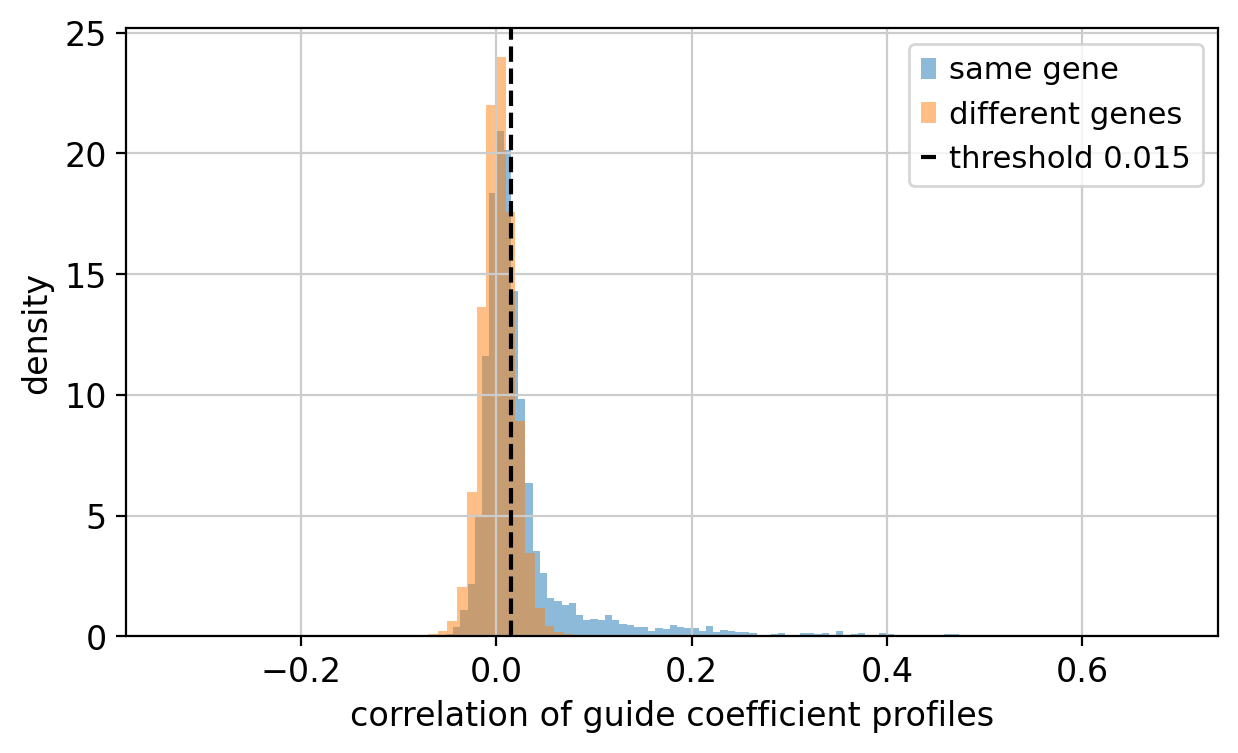

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
for flag, label in [(True, "same gene"), (False, "different genes")]:
    ax.hist(pairs.loc[pairs.same_gene == flag, "corr"], bins=100, density=True,
            alpha=0.5, label=label)
ax.axvline(par_guide_pair_corr_threshold, color="black", linestyle="--",
           label=f"threshold {par_guide_pair_corr_threshold}")
ax.set_xlabel("correlation of guide coefficient profiles")
ax.set_ylabel("density")
ax.legend()
plt.show()

## Select

For each gene: if every pair of its guides clears
`par_guide_pair_corr_threshold`, all are kept. Otherwise only the
best-correlated pair survives. Pairs with a non-positive correlation are
discarded either way, and a guide in no surviving pair is a bad guide.

In [5]:
same = pairs[pairs.same_gene].copy()

# Genes are visited in case-insensitive order, as the original's locale
# collation does: "Ldb2" comes before "LOC100861784", not after it.
groups = dict(list(same.groupby("gene_a", sort=False)))

kept = []
for gene in sorted(groups, key=str.lower):
    group = groups[gene]
    if (group["corr"] > par_guide_pair_corr_threshold).all():
        kept.append(group)
    else:
        kept.append(group.loc[[group["corr"].idxmax()]])

kept = pd.concat(kept) if kept else same.iloc[0:0]
kept = kept[kept["corr"] > 0]

good_guides = sorted(set(kept.guide_a) | set(kept.guide_b))
all_guides = list(weights.index)
bad_guides = sorted(g for g in all_guides if g not in good_guides)

print(f"genes considered: {same.gene_a.nunique()}")
print(f"surviving pairs : {kept.shape[0]}")
print(f"good guides     : {len(good_guides)}")
print(f"bad guides      : {len(bad_guides)}")

genes considered: 1119
surviving pairs : 2085
good guides     : 2256
bad guides      : 948


## Write

`par_bad_KO_guides_file` uses the column name `x`, which notebook 13 reads.

In [6]:
Path(par_good_guides_recomputed_file).parent.mkdir(parents=True, exist_ok=True)

# The original derives the two guide names by splitting a sorted pair key, so
# they come out alphabetically. Sort them here for the same reason.
pair_table = kept[["gene_a", "guide_a", "guide_b"]].copy()
ordered = [sorted([a, b]) for a, b in zip(pair_table.guide_a, pair_table.guide_b)]
pair_table["guide_a"] = [p[0] for p in ordered]
pair_table["guide_b"] = [p[1] for p in ordered]

pair_table.rename(
    columns={"gene_a": "GeneA", "guide_a": "guides_a", "guide_b": "guides_b"}
).to_csv(par_good_guides_recomputed_file, index=False)
print(f"written: {par_good_guides_recomputed_file}")

pd.DataFrame({"x": bad_guides}).to_csv(par_bad_KO_guides_recomputed_file, index=False)
print(f"written: {par_bad_KO_guides_recomputed_file}")
print(f"the lists used downstream are in TextFiles, left unchanged")

written: outputs/GuideSelect_GoodGuides_recomputed.csv
written: outputs/GuideSelect_BadKOGuides_recomputed.csv
the lists used downstream are in TextFiles, left unchanged
